## Problem Statement

> __Analyze experiment logs to identify trends in accuracy, training time, and performance across different model architectures and datasets.__

### Objectives:

> - To perform basic data cleaning and data preprocessing.
> - To perform Visualization by using matplotlib.
> - To analyze performance metrics such as Accuracy, Precision, Recall, and F1-score.
> - To use visual patterns to produce understandable insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset 

In [2]:
df = pd.read_csv("C:\\Users\\user5\\Downloads\\mlops_dataset.csv")
df

,experiment_id,run_date,model_architecture,dataset_name,dataset_version,learning_rate,batch_size,epochs,accuracy,precision,recall,f1_score,training_time_minutes,hardware_used,environment_details,notes
0,exp_0001,2023-08-17,XGBoost,ImageNet,3.0,0.00031,128,81,0.9659,0.9891,0.9758,0.9824,968,Cloud TPU,Windows 10 Python3.8,optimizer comparison
1,exp_0002,2023-02-21,SVM,ImageNet,1.0,0.00004,256,39,0.5764,0.5322,0.6130,0.5697,1584,Edge Device,Windows 10 Python3.8,tuned hyperparameters
2,exp_0003,2024-07-17,Transformer,IMDB,2.0,0.00254,128,5,0.8470,0.7991,0.8940,0.8439,1963,Edge Device,AWS EC2 Python3.10,regularization test
3,exp_0004,2024-05-16,XGBoost,SVHN,2.0,0.02137,256,18,0.6040,0.5722,0.5723,0.5722,1792,Edge Device,Windows 10 Python3.8,optimizer comparison
4,exp_0005,2024-04-02,XGBoost,CIFAR10,2.0,0.00016,64,25,0.7571,0.7503,0.7362,0.7432,1114,Cloud TPU,Ubuntu 20.04 Python3.8,loss function experiment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,exp_0096,2023-04-07,SVM,Custom,3.0,0.00003,64,77,0.8414,0.8543,0.8791,0.8665,1281,CPU,GCP Container Python3.7,tuned hyperparameters
96,exp_0097,2023-08-13,SVM,CIFAR10,2.0,0.00872,64,89,0.8937,0.8719,0.8614,0.8666,176,GPU,Ubuntu 22.04 Python3.9,data augmentation
97,exp_0098,2023-11-10,XGBoost,ImageNet,2.0,0.01006,16,57,0.8953,0.9444,0.8866,0.9146,932,Edge Device,GCP Container Python3.7,feature scaling applied
98,exp_0099,2023-11-24,Transformer,ImageNet,2.0,0.00031,64,95,0.8804,0.8645,0.9235,0.8930,589,Edge Device,MacOS 12 Python3.9,tuned hyperparameters


### 2. Checking rows and columns 

In [3]:
df.shape

(100, 16)

100 Rows and 16 columns are precent.

### 3. Display first 5 Rows

In [4]:
df.head()

,experiment_id,run_date,model_architecture,dataset_name,dataset_version,learning_rate,batch_size,epochs,accuracy,precision,recall,f1_score,training_time_minutes,hardware_used,environment_details,notes
0,exp_0001,2023-08-17,XGBoost,ImageNet,3.0,0.00031,128,81,0.9659,0.9891,0.9758,0.9824,968,Cloud TPU,Windows 10 Python3.8,optimizer comparison
1,exp_0002,2023-02-21,SVM,ImageNet,1.0,0.00004,256,39,0.5764,0.5322,0.6130,0.5697,1584,Edge Device,Windows 10 Python3.8,tuned hyperparameters
2,exp_0003,2024-07-17,Transformer,IMDB,2.0,0.00254,128,5,0.8470,0.7991,0.8940,0.8439,1963,Edge Device,AWS EC2 Python3.10,regularization test
3,exp_0004,2024-05-16,XGBoost,SVHN,2.0,0.02137,256,18,0.6040,0.5722,0.5723,0.5722,1792,Edge Device,Windows 10 Python3.8,optimizer comparison
4,exp_0005,2024-04-02,XGBoost,CIFAR10,2.0,0.00016,64,25,0.7571,0.7503,0.7362,0.7432,1114,Cloud TPU,Ubuntu 20.04 Python3.8,loss function experiment


It shows Top 5 Rows of dataset

### 4. Dispay Last 5 rows

In [5]:
df.tail()

,experiment_id,run_date,model_architecture,dataset_name,dataset_version,learning_rate,batch_size,epochs,accuracy,precision,recall,f1_score,training_time_minutes,hardware_used,environment_details,notes
95,exp_0096,2023-04-07,SVM,Custom,3.0,0.00003,64,77,0.8414,0.8543,0.8791,0.8665,1281,CPU,GCP Container Python3.7,tuned hyperparameters
96,exp_0097,2023-08-13,SVM,CIFAR10,2.0,0.00872,64,89,0.8937,0.8719,0.8614,0.8666,176,GPU,Ubuntu 22.04 Python3.9,data augmentation
97,exp_0098,2023-11-10,XGBoost,ImageNet,2.0,0.01006,16,57,0.8953,0.9444,0.8866,0.9146,932,Edge Device,GCP Container Python3.7,feature scaling applied
98,exp_0099,2023-11-24,Transformer,ImageNet,2.0,0.00031,64,95,0.8804,0.8645,0.9235,0.8930,589,Edge Device,MacOS 12 Python3.9,tuned hyperparameters
99,exp_0100,2025-05-14,RandomForest,CIFAR10,2.1,0.02714,256,89,0.7102,0.7353,0.7357,0.7355,1656,GPU,MacOS 12 Python3.9,tuned hyperparameters


The Last 5 Rows of dataset.

### 5. Basic Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   experiment_id          100 non-null    object 
 1   run_date               100 non-null    object 
 2   model_architecture     100 non-null    object 
 3   dataset_name           100 non-null    object 
 4   dataset_version        100 non-null    float64
 5   learning_rate          100 non-null    float64
 6   batch_size             100 non-null    int64  
 7   epochs                 100 non-null    int64  
 8   accuracy               100 non-null    float64
 9   precision              100 non-null    float64
 10  recall                 100 non-null    float64
 11  f1_score               100 non-null    float64
 12  training_time_minutes  100 non-null    int64  
 13  hardware_used          100 non-null    object 
 14  environment_details    100 non-null    object 
 15  notes  

By using this we will check Basic Information.

### 6. Finding Null values

In [6]:
pd.isnull(df).sum()

experiment_id            0
run_date                 0
model_architecture       0
dataset_name             0
dataset_version          0
learning_rate            0
batch_size               0
epochs                   0
accuracy                 0
precision                0
recall                   0
f1_score                 0
training_time_minutes    0
hardware_used            0
environment_details      0
notes                    0
dtype: int64

There are null values are not present.

### 7. Exploratory Data Analysis(EDA)

In [7]:
df.describe()

,dataset_version,learning_rate,batch_size,epochs,accuracy,precision,recall,f1_score,training_time_minutes
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.450000,0.011087,93.120000,52.670000,0.741317,0.740817,0.740065,0.739883,1017.210000
std,1.129092,0.018402,83.569034,27.007689,0.141771,0.147214,0.149391,0.147157,573.326009
min,1.000000,0.000010,16.000000,5.000000,0.504500,0.464600,0.479600,0.489900,14.000000
25%,2.000000,0.000110,32.000000,29.750000,0.616625,0.622875,0.607550,0.612950,524.000000
50%,2.100000,0.001210,64.000000,56.000000,0.753700,0.741550,0.749050,0.743200,973.000000
75%,3.000000,0.015270,128.000000,74.250000,0.847800,0.854400,0.874100,0.861775,1558.500000
max,4.200000,0.071530,256.000000,100.000000,0.985100,1.000000,1.000000,0.997900,1985.000000


By using this, We sees the count,mean, standard deviation , min,max, 25 % ,50% and &5 % of the column.

### 8. Name of columns

In [9]:
df.columns

Index(['experiment_id', 'run_date', 'model_architecture', 'dataset_name',
       'dataset_version', 'learning_rate', 'batch_size', 'epochs', 'accuracy',
       'precision', 'recall', 'f1_score', 'training_time_minutes',
       'hardware_used', 'environment_details', 'notes'],
      dtype='object')

We sees the name of all columns

### 9. Find Duplicates

In [8]:
df.duplicated().sum()

0

There is zero duplicates are present in this dataset.

### 10. Histogram for accuracy

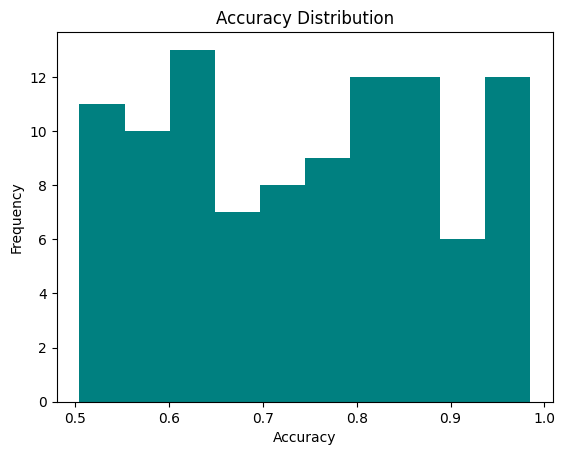

In [10]:
plt.hist(df['accuracy'],bins = 10,color = "teal")
plt.title("Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

we sees the accuracy of 10 bins

### 11. Scatter Plot (Learning Rate VS Accuracy)

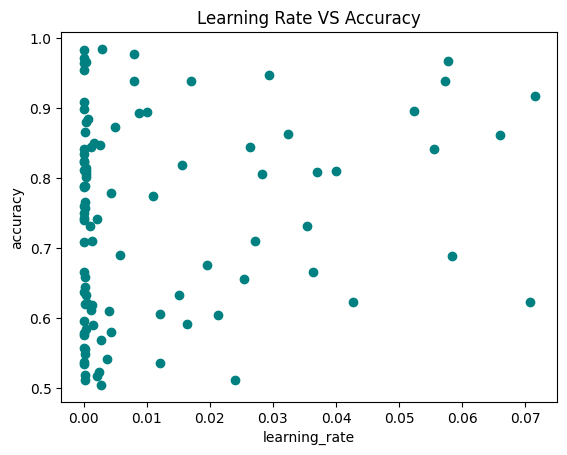

In [11]:
plt.scatter(df["learning_rate"],df["accuracy"],color="teal")
plt.title("Learning Rate VS Accuracy")
plt.xlabel("learning_rate")
plt.ylabel("accuracy")
plt.show()

Help to find learning rate range

### 12. Scatter Plot (Training Time VS Accuracy)

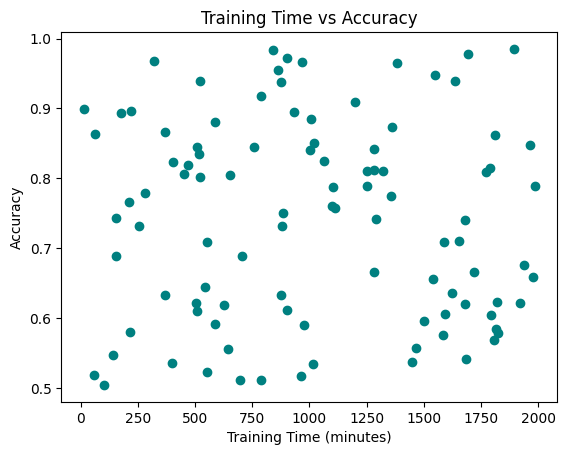

In [37]:
plt.scatter(df['training_time_minutes'], df['accuracy'],color="teal")
plt.xlabel("Training Time (minutes)")
plt.ylabel("Accuracy")
plt.title("Training Time vs Accuracy")
plt.show()

Shows Training time accuracy distribution.

### 13. Training time by hardware used

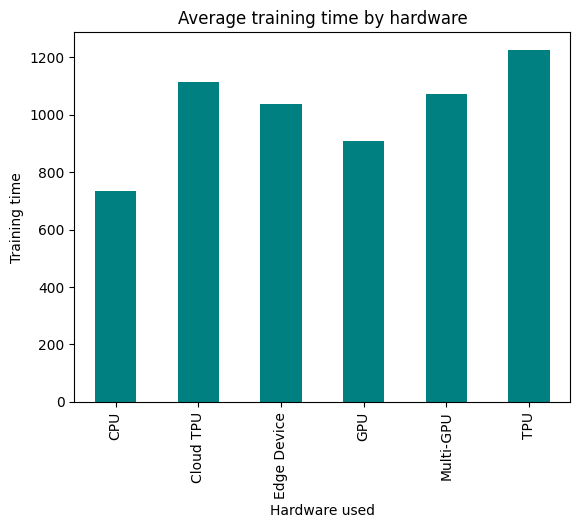

In [36]:
df.groupby('hardware_used')['training_time_minutes'].mean().plot(kind = 'bar',color="teal")
plt.title("Average training time by hardware")
plt.xlabel('Hardware used')
plt.ylabel('Training time')
plt.show()

We can sees that TPU is faster than other hardwares.

### 14. Accuracy over time 

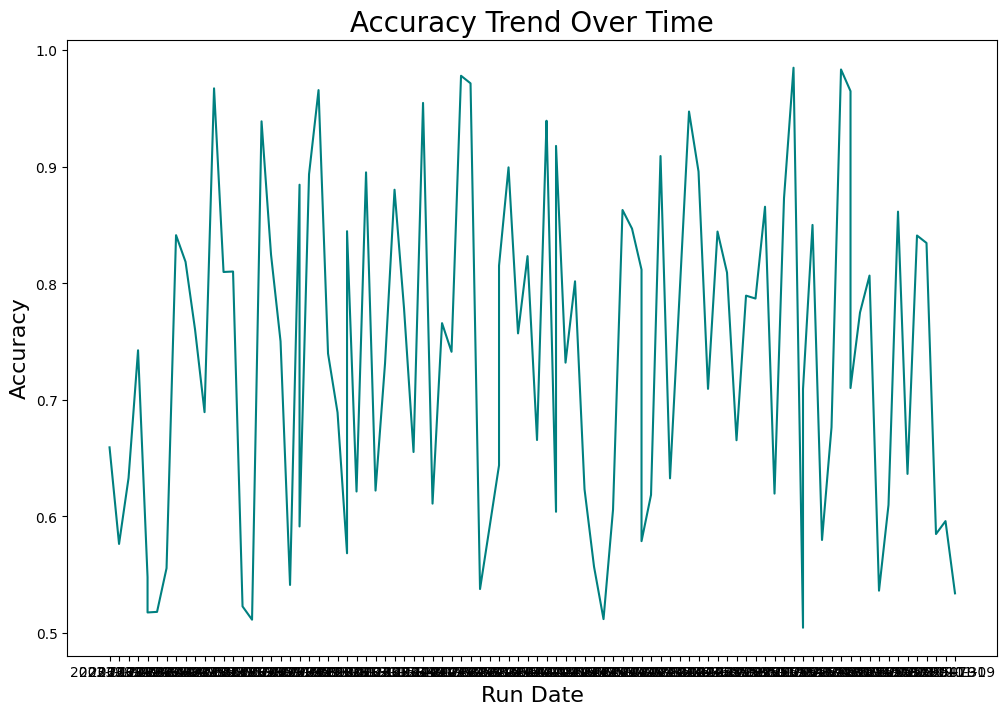

In [38]:
plt.figure(figsize = (12,8))
df_sorted = df.sort_values('run_date')
plt.plot(df_sorted["run_date"],df_sorted["accuracy"],color="teal")
plt.xlabel("Run Date", fontsize = 16)
plt.ylabel("Accuracy", fontsize = 16)
plt.title("Accuracy Trend Over Time", fontsize = 20)
plt.show()

### 15. Box Plot

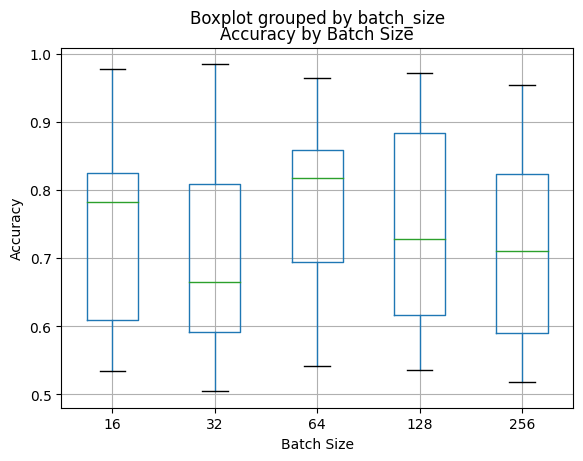

In [39]:
df.boxplot(column='accuracy', by='batch_size')
plt.title("Accuracy by Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.show()

Accuracy Spread for each batch size.

### 16. Comparision of Precission, Recall, F1 Score

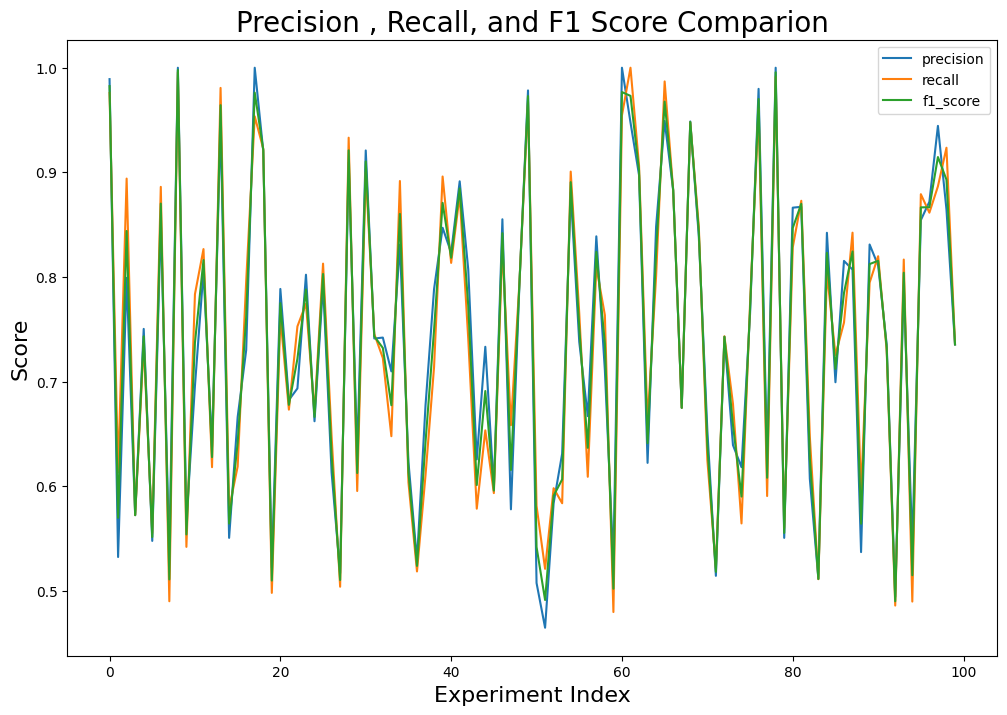

In [40]:
plt.figure(figsize = (12,8))
plt.plot(df['precision'],label='precision')
plt.plot(df['recall'],label='recall')
plt.plot(df['f1_score'],label='f1_score')
plt.title('Precision , Recall, and F1 Score Comparion',fontsize = 20)
plt.xlabel("Experiment Index",fontsize = 16)
plt.ylabel("Score", fontsize = 16)
plt.legend()
plt.show()

### Conclusion:

> This project proves that data analysis and visualization techniques can produce valuable result.Python, Pandas and graphs enable us to understand the overall behaviour of data, find patterns and differences and compare performance of different categories.